<a href="https://colab.research.google.com/github/nainikadevireddy/JohnsHopkinsAI/blob/main/Deep%20Neural%20Networks/7%3A%20Genomics%20Competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a> ©2021 onwards</font></small><hr style="margin:0;background-color:silver">

**<font size=6>🧬Genomics</font>**. [**Instructions**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=ITaPDPIQEgXV) for running Colabs.

<details>
  <summary><small>Sharing consent: <mark>[ X ]</mark></summary>
  <div>
We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes. We understand that sharing is <b>optional</b> and this decision will not affect our grade in any way. <font color=gray><i>
Instructions: If ok with sharing your Colab for educational purposes, leave "X" in the check box.</i></font></small></div>

In [ ]:
# from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json is stored in Google Drive

In [ ]:
!pip install --upgrade --force-reinstall --no-deps kaggle >> log  # upgrade kaggle package (to avoid a warning)
!mkdir -p ~/.kaggle                               # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >>log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!cp kaggle.json ~/.kaggle/kaggle.json >> log       # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                  # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 3mar25-genomics # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log              # download competition dataset as a zip file
!unzip -o *.zip >> log                            # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show           # print public leaderboard

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
- competition is now set to: 3mar25-genomics
Using competition: 3mar25-genomics
  teamId  teamName                  submissionDate              score         
--------  ------------------------  --------------------------  ------------  
13486293  Group_13_Nainika_Jenelle  2025-03-16 16:02:31.880000  0.9862000000  
13466996  5_Shuai_David             2025-03-16 13:23:57.493000  0.9859000000  
13496643  Josh Redmond              2025-03-15 22:49:48.773000  0.9856000000  
13432869  Sichao Liu                2025-03-15 22:54:37.560000  0.9856000000  
13473898  12_Kumar_Daniel           2025-03-16 00:17:28.396000  0.9853000000  
13478630  Seth Barshay              2025-03-16 12:51:39.133000  0.9853000000  
13490292  Jack Willis               2025-03-16 13:55:12.146000  0.9842000000  
13459604  Ray Tu                    2025-03-15 07:24:23.883000  0.9828000000  
13474036  Group_14_Oluwatobi_Eric   2025-03-16 16:

In [ ]:
%%time
%%capture
%reset -f
!pip install -U tfds-nightly sentence-transformers >> log
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, os, plotly, tensorflow as tf, tensorflow.keras as keras # tensorflow_addons as tfa
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer as SBERT
from keras.layers import Flatten, Dense
from sklearn.svm import SVC, LinearSVC
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60*5): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)
pd.set_option('display.max_rows', 100, 'display.max_columns', 100, 'display.max_colwidth', 100, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 9.25 s, sys: 1.59 s, total: 10.8 s
Wall time: 22.2 s


In [ ]:
vX = pd.read_csv('testX/testX.csv').set_index('id')
tYX = pd.read_csv('trainYX/trainYX.csv').set_index('id')
vX

,DNA
id,
100000,TTGATTAATAAGATTCCTTGACACCCTTTGTAAAGTTTCTATTTCGTGTGAAATATCTATCTCTTCAAATCCTTTTAATTTATCTAGGTATTTGCT...
100001,ATTAGTAACGGAGGATTTACTAGATGTTTGGATTTATATTCTAATTTTATTCAGGTGGAAGGGATTGTTTTATGATTCAATAGTATACAGAGAATA...
...,...
119998,CGTCGGCATGCTCGGGCAGTGCGGCGGGCCAGCAGCGTGCCAGTTGTCGCGGGGCGGCCGGGCATCGCGGCGCCGGGCGGCAGCACTCCCGCGAAG...
119999,GCGAGGGCACGAAGGCACGACGGCAACGGCGGCGAGGAGCGCTGTGGCAACCGTCTCCGCGTTTGCGTGCGTACAGCCGAGAGCTGGTTCGCGCAG...


In [ ]:
tmr = Timer() # runtime limit (in seconds). Add all of your code after the timer

⏳ started. You have 300 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

# Please Run with T4 GPU

In [ ]:
from sklearn.model_selection import StratifiedKFold
from collections import Counter
from itertools import product
from tensorflow.keras import layers
import random

os.environ['PYTHONHASHSEED'] = str(0)
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

In [ ]:
K = 4

# Generate all possible k-mers
kmers_list = [''.join(kmer) for kmer in product("ATCG", repeat=K)]

# Function to extract k-mer frequency features
def generate_kmers(sequence, k=K):
    kmers = [sequence[i:i+k] for i in range(len(sequence)-k+1)]
    return Counter(kmers)

def extract_kmer_features(sequences, k=K):
    feature_matrix = []
    for seq in sequences:
        kmer_counts = generate_kmers(seq, k)
        feature_matrix.append([kmer_counts.get(kmer, 0) for kmer in kmers_list])
    return np.array(feature_matrix)

# Convert DNA sequences to k-mer feature vectors
X_kmer = extract_kmer_features(tYX["DNA"], k=K)
y = tYX["Y"].values
print(f"Feature matrix shape: {X_kmer.shape}")

vX_kmer = extract_kmer_features(vX["DNA"], k=K)
print(f"Feature matrix shape: {vX_kmer.shape}")


Feature matrix shape: (100000, 256)
Feature matrix shape: (20000, 256)


In [ ]:
tf.random.set_seed(0)

X_train, X_val, y_train, y_val = train_test_split(X_kmer, y, test_size=0.2, random_state=0)

Init = keras.initializers.HeNormal(seed=3)

# Define the DNN model
model = keras.Sequential([
    layers.Dense(32, activation="relu", kernel_initializer=Init, input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu", kernel_initializer=Init),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu", kernel_initializer=Init),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")  # Binary classification
  ])

# Compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    )

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Evaluate on validation set
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
print(f"Validation Accuracy: {val_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9341 - loss: 0.1642 - val_accuracy: 0.9816 - val_loss: 0.0537
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9764 - loss: 0.0708 - val_accuracy: 0.9827 - val_loss: 0.0494
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9789 - loss: 0.0635 - val_accuracy: 0.9829 - val_loss: 0.0481
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9804 - loss: 0.0594 - val_accuracy: 0.9821 - val_loss: 0.0503
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9813 - loss: 0.0565 - val_accuracy: 0.9831 - val_loss: 0.0478
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9811 - loss: 0.0557 - val_accuracy: 0.9834 - val_loss: 0.0456
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9824 - loss: 0.0535 - val_accuracy: 0.9833 - val_loss: 0.0460
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9827 - loss: 0.0

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9850 - loss: 0.0452
Validation Accuracy: 0.9840


<font color=green><h3><b>$\delta$. Make predictions</b><h3>

In [ ]:
pY = pd.DataFrame(model.predict(vX_kmer), index=vX.index, columns=['y'])   # predicted targets
ToCSV((pY>0.5)*1, 'seeded_attempt2_32_64_32_0_3_dropout_henormal_relu_init_seed3')

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<font color=green><h3><b>$\epsilon$. Idea Documentation</b></h3>
<details>
  <summary>Instructions</summary>
  <div>


1. **Audience**. Your peers who will learn from your Colab and ideas therein.
1. **Importance**. The ML/DL ideas are not entirely random, but are based on prior experience and systematized/organized experiments. We'd like students to share and learn from idea generation to idea experimentation process done in our class using tools learned thus far.
1. **Format**. Keep it concise/precise in consistent font/presentation. Include numbers/IDs to your References, such as [1] or [[Géron22]](https://scholar.google.com/scholar?cluster=498861685923226475), where these are defined in your References section below. This helps link your ideas/experiments to external ideas.
1. **Reproducibility**. Your description should contain reasonable details needed for reproducibility, i.e. describe the state of your modeling pipeline before the change is made, what is changed and how the idea was discovered, and what improvement it resulted in. Thus, peers can try this idea with an expectation of the value it brings. See examples below.
1. **Bonus** points for the exceptional/exemplary/educational documentation (see grading rubric).
****
1. **TODO**: Describe the key idea in your work in the following format (similar to a "micro publication"):
  1. **Title**. Give each idea a descriptive name (i.e. a micro abstract).
    1. Ex(ample). <i>"Thresholding carat feature outliers improves MAE by 3% on public LB"</i>
  1. **Idea Discovery**. What led you to this idea? Was it some [EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis), familiarity with this dataset or some of the features?
    1. Ex. <i>"We plotted all univariate distributions of variables and discovered that diamond carat had unreasonable (but rare) values below and above [0,10] interval, when plotted carat's histogram in the train and test sets, which contained 10 and 3 such outliers respectively. We decided to use 10 as a reasonable threshold because it is 99th percentile of carat values in the 20K baseline sample. See our histogram plot below [plot here]. "</i>
  1. **Finding's Importance**. Describe why you think the idea was important to proceed with.
    1. Ex. <i>"We use a linear model, the slope of which is sensitive to outliers on the periphery of the feature space domain. The fitted hyperplane slopes in the direction of the extreme training feature values thereby mapping a non-existent relation between carat size and diamond price, which is not expected to repeat in the test set. "</i>
  1. **Experiment Setup**.
  How did you set up experiments to test your idea? What resources were helpful? What metric did you select, why and what values did you observe?
    1. Ex. <i>"To alleviate the impact of the outlying feature values, we need to either remove observations with extreme values, or somehow cap them (to stay within the distribution of the other carat values) or use a model insensitive to outliers (such as robust regression). We learned 3 suitable methods for treating outliers in [ref]: ... [It'd be great to briefly describe each method] We tried each one on a Baseline model, while keeping the competition-required [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) metric. We tested each method locally on the seeded 50/50 split of the 20K training set sampled in baseline Colab."</i>
  1. **Results**. What was the result or metric improvement from implementing the experiment locally and/or on public LB?
    1. Ex. <i>"Baseline MAE was 539.1257546465 in public LB and 530 in local default experiment with 50/50 train-test split. When applied on the same-seed split, Methods 1,2,and 3 showed 1%, 2%, and 5% improvement on the test set. When uploaded to public LB, Method 3 showed a 3% improvement. So, we decided to keep method 3."</i>

</div> </details>
</font>


<font color=green><h4><b>Task 1. Preprocessing Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped in <b>preprocessing pipeline</b>. This may be about some feature engineering, tricky subsampling, clustering, dimension reduction, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: K-mer Encoding
1. **Idea Discovery**: Genome sequences are made up of four nucleotides - A, T, G and C. These nucleotide sequences form the building blocks of genetic information, encoding the instructions necessary for biological function. K-mers are substrings of length k extracted from a larger DNA sequence. In genomics, k-mers play a large role in sequence analysis. They capture local sequence patterns and structural motifs in the DNA sequence. Since different organisms exhibit distinct k-mer frequency distributions, these patterns are optimal for classification tasks. Instead of relying on sequence alignment, which can be computationally expensive, k-mers offer a feature-based approach that converts sequences into structured numerical representations. For example, for k-mer = 3, 64 features that are permutations of the four nucleotides are generated. (e.g. ATC, GTA, TAG, AAT, etc.).
1. **Finding's Importance**: K-mer encoding allows for converting the letter-based sequence into a numerical representation, holding valuable biological structure information that may facilitate classification. Additionally, the encoding allows for dimensionality reduction by converting lengthy DNA sequences into a fixed number of features. This also allows for a common feature set across data points.
1. **Experiment Setup**: We extracted k-mers of length k=3 and k=4 from labeled bacterial DNA sequences and converted them into numerical feature vectors using the frequency of each k-mer sequence. These features were normalized using StandardScaler and used to train a baseline 3-layer deep neural network with batch normalization, and dropout. The model was evaluated using 5-fold cross-validation for k=3 (64 features, k=4 (256 features), [k=4 + k=3] (320 features) and k=5 (1024 features).
1. **Results**: The combination of k=4 and k=3 k-mers resulted in the higher cross-fold accuracy (0.9844), performing slightly higher than k=3 (0.9830) and k=4 (0.9841) separately. This suggests that the combination of 3-mers and 4-mers were able to capture different biological features of the DNA sequence that allowed for better classification. The k=5 attempts scored the lowest accuracy and resulted in a slower runtime, suggesting that the feature set was too large, redundant or introducing noise into the dataset.


<font color=green><h4><b>Task 2. Modeling Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped with <b>model selection</b> in the format specified above. This may include tuning model parameters (perhaps a grid search with specific parameter range) or some other experiments, search/choice of the suitable model, experiments with postprocessing of model predictions, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Neural Network Improves Upon Baseline Linear SVC by 4.26%
1. **Idea Discovery**: We saw that the starter notebook had a sequential neural network with dense connections commented out. Due to the success of neural networks in achieving close to 100% accuracy in previous competitions, we elected to try this model as well.
1. **Finding's Importance**: Chapter 5 pages 156-158 of [1] discuss the decision boundary of Linear SVC and note that it is limited by the fact it is a straight-line decision boundary. Bacteria sequences can contain multiple complex dependencies, patterns, and motifs that this linear decision boundary may not be able to capture. Furthermore, neural networks contain layers which can build a hierarchy of representations from more literal patterns to abstract features as the data flows deeper into the network. Therefore, neural networks could perform significantly better at this task.
1. **Experiment Setup**: For the neural network, a densely connected sequential neural network with random initialization, adam optimizer, binary cross entropy loss, and output layer with sigmoid activation was used. Each layer had ReLU activation, batch normalization, 0.3 dropout, and the network configuration was 3 layers with 64, 64, and 32 nodes respectively. This model was trained for 20 epochs with a batch size of 64. A 80/20 train/validation split was used, where the input was preprocessed by generating k-mer feature vectors. Performance was determined using best validation accuracy. This was compared to the LinearSVC in the starter Colab Notebook.
1. **Results**: Locally and on the public leaderboard the neural network performs better achieving an accuracy of 98.49% on the public leaderboard compared to the baseline 94.23%.

1. **Title**:  Early Stopping Allows for Best Checkpoint to Be Saved
1. **Idea Discovery**: Throughout experimenting, we noticed that the highest validation accuracy often came before the 20th epoch, and we had plenty of runtime left to train for these 20 epochs. Therefore the final saved model was not capturing the optimal weights but rather an overfit network.
1. **Finding's Importance**: While it is important for a network to not overfit, to know when the network is overfitting, one may have to train past the perfect fit but training too far wastes time.
1. **Experiment Setup**: No experiment was conducted, we simply observed that this would give us a better model according to training and validation accuracy (see table in results). In this case, those results come from a model with the following specifications. A densely connected sequential neural network with random initialization, adam optimizer, binary cross entropy loss, early stopping with patience 5 (restoring best weights), and output layer with sigmoid activation was used. Each layer had ReLU activation, batch normalization, and the network configuration was 3 layers with 64, 32, and 32 nodes respectively. This model was trained for 20 epochs with a batch size of 64. A 80/20 train/validation split was used, where the input was preprocessed by generating k-mer feature vectors. Performance was determined using best validation accuracy.
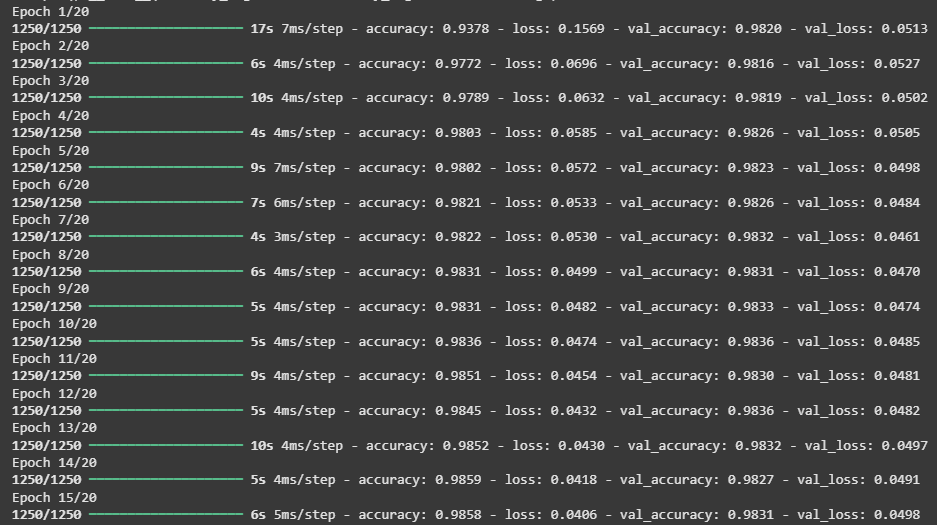

1. **Results**: Implementing early stopping with patience of 5 epochs and restoring best weights ensured the best weights from our model were saved.

1. **Title**: 0.3 Dropout Rate Improves Accuracy by up to 0.2% Compared to Other Dropout Rates
1. **Idea Discovery**: Again, our model converged before 20 epochs so we thought it important to investigate techniques which would deter overfitting.
1. **Finding's Importance**: During training, dropout randomly sets a fraction of neurons to 0 in each layer. The randomness forces the layer to not depend on specific neurons which translates to learning more robust features. [2] demonstrates this in a compelling visual manner.
1. **Experiment Setup**: We experimented with 3 different dropout rates: 0.3, 0.4, 0.5 for all the layers. In each experiment, a densely connected sequential neural network with random initialization, adam optimizer, binary cross entropy loss, early stopping with patience 5 (restoring best weights), and output layer with sigmoid activation was used. Each layer had ReLU activation, batch normalization, and the network configuration was 3 layers with 64, 64, and 32 nodes respectively. This model was trained for 20 epochs with a batch size of 64. A 80/20 train/validation split was used, where the input was preprocessed by generating k-mer feature vectors. Performance was determined using best validation accuracy.
1. **Results**: See table below. 0.3 dropout for each layer performed best in terms of validation accuracy and train accuracy and therefore was submitted to the public leaderboard.

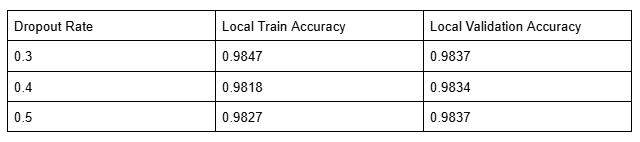

1. **Title**: ReLU Activation Function Outperforms ELU an SELU for this Use Case
1. **Idea Discovery**: Chapter 11 page 332 of [1], lists a relative ranking of activation functions. This ranking states that in general SELU is better than ELU is better than leaky ReLU is better than ReLU. Therefore, we thought of trying other activation functions than ReLU.
1. **Finding's Importance**: ReLU is computationally efficient, simple, and helps to avoid vanishing gradients for positive inputs, so it is a clear starting candidate for any neural network. However, it can lead to many neurons becoming inactive if inputs to the activation function are negative. ELU therefore introduces a smooth negative saturation where neurons with negative input can still learn and update; this comes at a computational expense. SELU is designed to self-normalize which means it drives activations toward 0 mean and variance which can be helpful for deep networks. Ultimately, each function has a unique impact on the outputs of each neuron, particularly when it comes to negative inputs, which can be extremely influential to weight updates and outputs. Although only ReLU, sigmoid, linear, and tanh activation functions are available here, the Tensorflow Playground visualization in [3] conveys the effect activation function can have on neurons and weight values with the color gradient in the graph.
1. **Experiment Setup**: We experimented with 3 different types of activation functions: SELU, ELU, ReLU for the layers. In each experiment, a densely connected sequential neural network with random initialization, adam optimizer, binary cross entropy loss, early stopping with patience 5 (restoring best weights), and output layer with sigmoid activation was used. Each layer had batch normalization, 0.3 dropout, and the network configuration was 3 layers with 64, 64, and 32 nodes respectively. This model was trained for 20 epochs with a batch size of 64. A 80/20 train/validation split was used, where the input was preprocessed by generating k-mer feature vectors. Performance was determined using best validation accuracy.
1. **Results**: Ultimately, ELU and SELU activation functions showed higher accuracy when tested locally. However, when tested on the public leaderboard ReLU was the clear choice, achieving over 98% accuracy, described above in the best dropout experiment,

1. **Title**: HeNormal Initialization
1. **Idea Discovery**: Chapter 11 of [1], shows table 11-1 which states He initialization is useful for networks using ReLU activation functions.
1. **Finding's Importance**: Relu activation functions convert negative inputs to zeroes [1]. This function reduces the signal passed through the network. He initialization compensates for this by scaling weights to help preserve variance despite loss of information from negative values which go to zero.
1. **Experiment Setup**: We experimented with 3 different types of initialization functions: randomNormal, HeNormal, and lecunNormal. In each experiment, a densely connected sequential neural network with adam optimizer, binary cross entropy loss, early stopping with patience 5 (restoring best weights), and output layer with sigmoid activation was used. Each layer had batch normalization, 0.3 dropout, and the network configuration was 3 layers with 64, 64, and 32 nodes respectively. For the lecunNormal initializer, SELU activation was used for reasons stated above but otherwise ReLU was used in accordance with the result in the previous documentation. This model was trained for 20 epochs with a batch size of 64. A 80/20 train/validation split was used, where the input was preprocessed by generating k-mer feature vectors. Performance was determined using best validation accuracy.
1. **Results**: Locally, lecunNormal performed the best with 98.38% accuracy and 98.34% validation accuracy closely followed by HeNormal with 98.35% accuracy and 98.33% validation accuracy. Random normal performed the worst. However, on the leaderboard lecunNormal initialization shockingly resulted in 92.09% accuracy while HeNormal resulted in 98.57% accuracy. Therefore HeNormal initialization was chosen.

1. **Title**:  Node Configuration Can Improve Results Up to 0.15% on the Public Leaderboard
1. **Idea Discovery**: Arranging a layer with more nodes before a layer with fewer nodes forces the neural network to compress information. This bottleneck can help the model focus on the most salient features; however, if this compression is too strict, important details may be lost. Each configuration of layers therefore reflects this compression and expansion of information which can lead to drastically different learned representations.
1. **Finding's Importance**: Arranging a layer with more nodes before a layer with fewer nodes forces the neural network to compress information. This bottleneck can help the model focus on the most salient features; however, if this compression is too strict, important details may be lost. Each configuration of layers therefore reflects this compression and expansion of information which can lead to drastically different learned representations.
1. **Experiment Setup**:  We experimented with many different network configurations. In each experiment, a densely connected sequential neural network with HeNormal initialization, adam optimizer, binary cross entropy loss, early stopping with patience 5 (restoring best weights), and output layer with sigmoid activation was used. Each layer had batch normalization, 0.3 dropout, and ReLU activation function. This model was trained for 20 epochs with a batch size of 64. A 80/20 train/validation split was used, where the input was preprocessed by generating k-mer feature vectors. Performance was determined using best validation accuracy. The configurations tested are: (64, 32, 32), (64, 64, 32), (32, 32, 64), and (32, 64, 32) where each network is 3 layers and each number inside the parentheses represents the number of nodes in that layer.
1. **Results**: Ultimately, the (32, 64, 32) node configuration performed best achieving a local validation accuracy of 0.9841 and a public leaderboard accuracy of 0.9862. This was followed by the (64, 64, 32) node configuration which achieved 0.9858 accuracy on the public leaderboard and the (32, 32, 64) configuration which achieved 0.9849 accuracy on the public leaderboard.

<font color=green><h3><b>$\zeta$. References</b></h3>
<details>
  <summary>Instructions</summary>
  <div>

1. Cite your sources to help your peers learn from these (and to avoid plagiarism).
1. HOML textbook should be cited, since we used it in this week's learning.
1. Use Google Scholar to draw [APA](https://en.wikipedia.org/wiki/American_Psychological_Association) citation format for books and publications.
1. Cite [StackOverflow](https://stackoverflow.com/), YouTube videos, package docs, open-access textbooks/publicaitons and other meaningful internet resources that you used.
1. We may reward exceptional and meaningful citations (not just a list of [SKL](https://scikit-learn.org/stable/)/[TF](https://www.tensorflow.org/) manual pages and a list of articles.) For example, if you used an idea from a publication, indicate it in TGP with a number that corresponds to its reference in References.

</div> </details>
</font>

1. Geron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras & Tensorflow. 2nd Ed., Sebastopol, CA: O’Reilly, 2019.
2. sentdex. (2020, October 6). Dropout visualized. https://nnfs.io/def/  
3. Carter, D. S. (n.d.). Tensorflow - Neural Network Playground. A Neural Network Playground. https://playground.tensorflow.org/  


<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 167 sec


<details>
  <summary><font size=5><b>💡Starter Ideas</b></font></summary>
  <div>
  
1. Learn about DNA [&#127910;](https://www.youtube.com/results?search_query=nucleotides+genes+amino+acids+)
1. Try a larger training sample.
1. Try longer training DNA strings, but SBERT may have a cap on string length, so you might split DNA into several strings and then concatenate or average resulting vectors
1. Try other pretrained SBERT models. Note that DNA sequence uses ACGT letters, but many other models were trained on multilingual text. So, you might prefer those that were trained on mostly ASCII.
1. SBERT is trained on word tokens (typically, separated by spaces), but DNA sequence has no spaces. Try placing spaces after every character or some semantically meaningful subsequences (this might require more domain knowledge).
1. Try Google's [USE](https://tfhub.dev/google/universal-sentence-encoder-multilingual/3) embedding models
1. Try Facebook's [LASER](https://github.com/facebookresearch/LASER) and [others](https://tfhub.dev/s?module-type=text-language-model).
1. Try [Enformer](https://tfhub.dev/deepmind/enformer/1) for gene expressions. See [DeepMind paper](https://deepmind.com/blog/article/enformer).
1. Try building your own embeddings on the given sequences. SBERT and other packages make it easy (just a few lines), but it may take too much time.
1. Assess distribution of character patterns (single, doubles, triplets, ...). For example, an ACGT string generates AC, CG, GT doubles and ACG and CGT triplets. Does one class have more subsequences of some type? This might be a feature in your model.
1. Try features built as counts of subsequences (singles, doubles, triplets, ...). Consider EDA first.
1. Concatenate or otherwise combine multiple embeddings derived from each gene string
1. Learn from [*The genetic code*](https://www.khanacademy.org/science/ap-biology/gene-expression-and-regulation/translation/a/the-genetic-code-discovery-and-properties), Khan Academy.
1. Learn from [*Apply Machine Learning Algorithms for Genomics Data Classification*](https://medium.com/mlearning-ai/apply-machine-learning-algorithms-for-genomics-data-classification-132972933723)
1. Learn from [*Efficient counting of k-mers in DNA sequences using a bloom filter*](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-12-333) Páll Melsted et al. 2011
1. Try [Byte Pair Encoding](https://www.derczynski.com/papers/archive/BPE_Gage.pdf) and [SentencePiece](https://arxiv.org/pdf/1808.06226.pdf) to auto identification of "important" [k-mers](https://en.wikipedia.org/wiki/K-mer) (substrings)

</div> </details>